# 05 - Ensemble CNN + KNN
**Kompetisi:** INFEST XII 2026 - Data Science (Klasifikasi Aksara Tradisional Nusantara)
**Tim:** Fadhil - Percobaan 1

**Latar belakang:** CNN (ResNet18 fine-tuned) mencapai Val F1 Macro 0.9939, Kaggle Public Score
0.9616. Analisis error menunjukkan 100% kesalahan model (5 dari 671 sampel val) terjadi antara
kelas `jawi` dan `pegon` -- dua aksara berbasis Arab yang mirip secara visual.

**Ide eksperimen:** gunakan CNN yang sudah dilatih sebagai *feature extractor* (ambil output
sebelum layer FC terakhir sebagai embedding), lalu latih KNN di atas embedding tersebut. Prediksi
akhir merupakan **ensemble** (gabungan) antara softmax CNN dan KNN, dengan harapan KNN bisa
menangkap pola kedekatan lokal yang berbeda dari boundary keputusan CNN, khususnya untuk kasus
ambigu `jawi`-`pegon`.

**Catatan penting (ekspektasi realistis):** karena Val F1 CNN sudah 0.9939, ruang improvement
sangat sempit. Eksperimen ini kemungkinan besar hasilnya netral atau improvement sangat kecil.
Nilai utama eksperimen ini adalah sebagai **ablation study** untuk laporan (menunjukkan proses
eksplorasi metodologi), bukan untuk mengganti model utama, kecuali terbukti benar-benar lebih baik
di validation set.

**Isi notebook:**
1. Setup & Load Model CNN Terlatih
2. Ekstraksi Embedding (Train, Val, Test)
3. Training KNN pada Embedding
4. Evaluasi KNN Saja (Pembanding)
5. Ensemble: Weighted Average CNN + KNN
6. Tuning Bobot Ensemble & K (Grid Search Sederhana)
7. Evaluasi Akhir & Keputusan
8. Generate Submission (jika ensemble terbukti lebih baik)


## 1. Setup & Load Model CNN Terlatih

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "../dataset"
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "images", "train")
TEST_IMG_DIR = os.path.join(DATA_DIR, "images", "test")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
ARTIFACT_DIR = "../artifacts"
OUTPUT_DIR = "../submissions"

with open(os.path.join(ARTIFACT_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

TARGET_SIZE = tuple(config["target_size"])
classes_sorted = config["classes"]
label_to_idx = config["label_to_idx"]
idx_to_label = {v: k for k, v in label_to_idx.items()}

train_split_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "train_split.csv"))
val_split_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "val_split.csv"))
test_df = pd.read_csv(TEST_CSV)

print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)} | Test: {len(test_df)}")


Device: cuda
Train: 3796 | Val: 671 | Test: 1118


In [2]:
def resize_with_padding(img, target_size=TARGET_SIZE, fill_color=(255, 255, 255)):
    img = img.convert("RGB")
    original_w, original_h = img.size
    target_w, target_h = target_size
    ratio = min(target_w / original_w, target_h / original_h)
    new_w, new_h = int(original_w * ratio), int(original_h * ratio)
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    new_img = Image.new("RGB", target_size, fill_color)
    paste_x = (target_w - new_w) // 2
    paste_y = (target_h - new_h) // 2
    new_img.paste(img_resized, (paste_x, paste_y))
    return new_img

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
to_tensor_normalize = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class AksaraDatasetSimple(Dataset):
    """Dataset tanpa augmentasi -- dipakai untuk ekstraksi embedding (train/val/test)."""
    def __init__(self, df, img_dir, has_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.has_label = has_label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        img = Image.open(img_path)
        img = resize_with_padding(img)
        tensor = to_tensor_normalize(img)
        if self.has_label:
            return tensor, label_to_idx[row['label']], row['image_id']
        return tensor, row['image_id']


In [3]:
def build_resnet_model(num_classes):
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

checkpoint = torch.load(os.path.join(ARTIFACT_DIR, "best_model.pt"), map_location=DEVICE)

cnn_model = build_resnet_model(num_classes=len(classes_sorted)).to(DEVICE)
cnn_model.load_state_dict(checkpoint["model_state_dict"])
cnn_model.eval()

print(f"CNN checkpoint di-load, Val F1 Macro tercatat: {checkpoint['val_f1']:.4f}")

# Feature extractor: ambil semua layer ResNet18 KECUALI fc terakhir
# ResNet18: ...avgpool menghasilkan (batch, 512, 1, 1) sebelum fc
feature_extractor = nn.Sequential(*list(cnn_model.children())[:-1]).to(DEVICE)
feature_extractor.eval()

print("Feature extractor siap. Output embedding dimension: 512 (ResNet18 avgpool)")


CNN checkpoint di-load, Val F1 Macro tercatat: 0.9939
Feature extractor siap. Output embedding dimension: 512 (ResNet18 avgpool)


## 2. Ekstraksi Embedding (Train, Val, Test)

Embedding diambil dari output `avgpool` ResNet18 (dimensi 512), sebelum masuk ke layer fully
connected. Embedding ini merepresentasikan fitur visual tingkat tinggi yang sudah dipelajari CNN
selama fine-tuning.

In [4]:
@torch.no_grad()
def extract_embeddings(feature_extractor, loader, device, has_label=True):
    all_embeddings, all_labels, all_ids = [], [], []

    for batch in loader:
        if has_label:
            images, labels, img_ids = batch
        else:
            images, img_ids = batch

        images = images.to(device)
        features = feature_extractor(images)          # (batch, 512, 1, 1)
        features = features.squeeze(-1).squeeze(-1)    # (batch, 512)

        all_embeddings.append(features.cpu().numpy())
        all_ids.extend(img_ids)
        if has_label:
            all_labels.extend(labels.numpy())

    embeddings = np.concatenate(all_embeddings, axis=0)
    if has_label:
        return embeddings, np.array(all_labels), list(all_ids)
    return embeddings, list(all_ids)


train_dataset_emb = AksaraDatasetSimple(train_split_df, TRAIN_IMG_DIR, has_label=True)
val_dataset_emb = AksaraDatasetSimple(val_split_df, TRAIN_IMG_DIR, has_label=True)
test_dataset_emb = AksaraDatasetSimple(test_df, TEST_IMG_DIR, has_label=False)

train_loader_emb = DataLoader(train_dataset_emb, batch_size=32, shuffle=False, num_workers=0)
val_loader_emb = DataLoader(val_dataset_emb, batch_size=32, shuffle=False, num_workers=0)
test_loader_emb = DataLoader(test_dataset_emb, batch_size=32, shuffle=False, num_workers=0)

print("Ekstraksi embedding train...")
train_embeddings, train_labels_emb, train_ids_emb = extract_embeddings(feature_extractor, train_loader_emb, DEVICE, has_label=True)

print("Ekstraksi embedding val...")
val_embeddings, val_labels_emb, val_ids_emb = extract_embeddings(feature_extractor, val_loader_emb, DEVICE, has_label=True)

print("Ekstraksi embedding test...")
test_embeddings, test_ids_emb = extract_embeddings(feature_extractor, test_loader_emb, DEVICE, has_label=False)

print(f"Train embeddings: {train_embeddings.shape}")
print(f"Val embeddings  : {val_embeddings.shape}")
print(f"Test embeddings : {test_embeddings.shape}")


Ekstraksi embedding train...
Ekstraksi embedding val...
Ekstraksi embedding test...
Train embeddings: (3796, 512)
Val embeddings  : (671, 512)
Test embeddings : (1118, 512)


In [5]:
# Simpan embedding sebagai artefak, supaya tidak perlu ekstraksi ulang tiap kali eksperimen
np.savez(
    os.path.join(ARTIFACT_DIR, "embeddings.npz"),
    train_embeddings=train_embeddings, train_labels=train_labels_emb,
    val_embeddings=val_embeddings, val_labels=val_labels_emb,
    test_embeddings=test_embeddings,
)
print("Embedding tersimpan di artifacts/embeddings.npz")


Embedding tersimpan di artifacts/embeddings.npz


## 3. Training KNN pada Embedding

KNN dilatih pada embedding train set (bukan gambar mentah). Mulai dengan `k=5` sebagai baseline,
akan di-tuning lebih lanjut di Section 6.

In [6]:
K_DEFAULT = 5

knn_model = KNeighborsClassifier(n_neighbors=K_DEFAULT, metric='cosine', weights='distance')
knn_model.fit(train_embeddings, train_labels_emb)

knn_val_preds = knn_model.predict(val_embeddings)
knn_val_probs = knn_model.predict_proba(val_embeddings)

knn_f1 = f1_score(val_labels_emb, knn_val_preds, average='macro')
print(f"KNN (k={K_DEFAULT}) Val F1 Macro: {knn_f1:.4f}")


KNN (k=5) Val F1 Macro: 0.9939


## 4. Evaluasi KNN Saja (Pembanding)

Bandingkan performa KNN murni dengan CNN murni (softmax), sebelum masuk ke ensemble.

In [7]:
@torch.no_grad()
def predict_cnn_softmax(model, loader, device, has_label=True):
    all_preds, all_probs, all_labels, all_ids = [], [], [], []

    for batch in loader:
        if has_label:
            images, labels, img_ids = batch
        else:
            images, img_ids = batch

        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_ids.extend(img_ids)
        if has_label:
            all_labels.extend(labels.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    if has_label:
        return np.array(all_preds), all_probs, np.array(all_labels), list(all_ids)
    return np.array(all_preds), all_probs, list(all_ids)


cnn_val_preds, cnn_val_probs, cnn_val_labels, cnn_val_ids = predict_cnn_softmax(
    cnn_model, val_loader_emb, DEVICE, has_label=True
)
cnn_f1 = f1_score(cnn_val_labels, cnn_val_preds, average='macro')

print(f"CNN murni Val F1 Macro : {cnn_f1:.4f}")
print(f"KNN murni Val F1 Macro : {knn_f1:.4f}")

# Pastikan urutan sampel val dari kedua loader konsisten sebelum digabung
assert cnn_val_ids == val_ids_emb, "Urutan sampel val tidak konsisten antar loader!"
assert (cnn_val_labels == val_labels_emb).all(), "Label val tidak konsisten antar loader!"


CNN murni Val F1 Macro : 0.9939
KNN murni Val F1 Macro : 0.9939


> **Catatan interpretasi (isi manual):**
> - Apakah KNN murni lebih baik, sama, atau lebih buruk dari CNN murni?
> - Kalau KNN jauh lebih buruk, itu wajar -- KNN tidak fine-tuned untuk task ini, cuma memanfaatkan
>   representasi fitur yang sudah dipelajari CNN. Tujuan bukan mengalahkan CNN sendirian, tapi
>   melihat apakah KNN bisa MELENGKAPI CNN di kasus-kasus tertentu (lihat Section 5).

## 5. Ensemble: Weighted Average CNN + KNN

Gabungkan probabilitas CNN (softmax) dan KNN (predict_proba) dengan **weighted average**.
Bobot `alpha` mengatur seberapa besar kontribusi CNN vs KNN:

```
final_probs = alpha * cnn_probs + (1 - alpha) * knn_probs
```

`alpha = 1.0` berarti murni CNN (baseline), `alpha = 0.0` berarti murni KNN.

In [8]:
def ensemble_predict(cnn_probs, knn_probs, alpha):
    combined = alpha * cnn_probs + (1 - alpha) * knn_probs
    preds = combined.argmax(axis=1)
    return preds, combined

# Coba dengan alpha awal 0.7 (CNN lebih dominan, KNN sebagai pelengkap)
alpha_initial = 0.7
ensemble_val_preds, ensemble_val_probs = ensemble_predict(cnn_val_probs, knn_val_probs, alpha_initial)
ensemble_f1 = f1_score(val_labels_emb, ensemble_val_preds, average='macro')

print(f"Ensemble (alpha={alpha_initial}) Val F1 Macro: {ensemble_f1:.4f}")
print(f"Dibanding CNN murni ({cnn_f1:.4f}): {'LEBIH BAIK' if ensemble_f1 > cnn_f1 else 'TIDAK LEBIH BAIK'}")


Ensemble (alpha=0.7) Val F1 Macro: 0.9939
Dibanding CNN murni (0.9939): TIDAK LEBIH BAIK


## 6. Tuning Bobot Ensemble & K (Grid Search Sederhana)

Cari kombinasi `alpha` (bobot ensemble) dan `k` (jumlah tetangga KNN) yang menghasilkan Val F1
Macro terbaik. Grid search sederhana karena ruang parameter kecil dan dataset tidak terlalu besar.

In [9]:
k_candidates = [3, 5, 7, 9, 11, 15]
alpha_candidates = np.arange(0.0, 1.01, 0.1)

results = []

for k in k_candidates:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='cosine', weights='distance')
    knn_k.fit(train_embeddings, train_labels_emb)
    knn_k_val_probs = knn_k.predict_proba(val_embeddings)

    for alpha in alpha_candidates:
        preds, _ = ensemble_predict(cnn_val_probs, knn_k_val_probs, alpha)
        f1 = f1_score(val_labels_emb, preds, average='macro')
        results.append({"k": k, "alpha": round(alpha, 2), "val_f1_macro": f1})

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df["val_f1_macro"].idxmax()]
print("Kombinasi terbaik:")
print(best_row)
print()
print(f"CNN murni (alpha=1.0) sebagai referensi: {cnn_f1:.4f}")


Kombinasi terbaik:
k               3.000000
alpha           0.300000
val_f1_macro    0.995085
Name: 3, dtype: float64

CNN murni (alpha=1.0) sebagai referensi: 0.9939


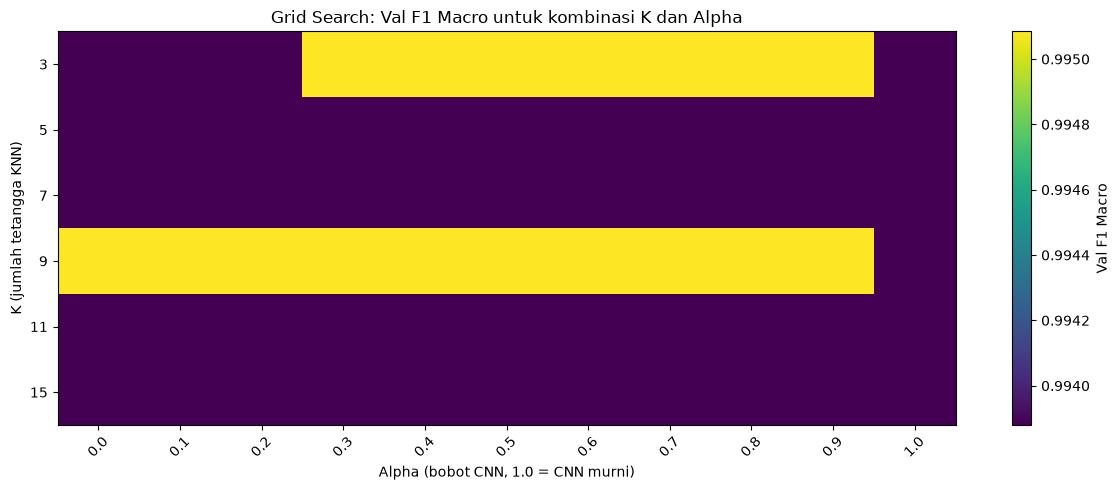

In [10]:
# Visualisasi heatmap hasil grid search
pivot = results_df.pivot(index="k", columns="alpha", values="val_f1_macro")

plt.figure(figsize=(12, 5))
plt.imshow(pivot, aspect='auto', cmap='viridis')
plt.colorbar(label='Val F1 Macro')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), [f"{a:.1f}" for a in pivot.columns], rotation=45)
plt.xlabel("Alpha (bobot CNN, 1.0 = CNN murni)")
plt.ylabel("K (jumlah tetangga KNN)")
plt.title("Grid Search: Val F1 Macro untuk kombinasi K dan Alpha")
plt.tight_layout()
plt.show()


> **Catatan interpretasi (isi manual):**
> - Apakah ada kombinasi (k, alpha) yang mengalahkan CNN murni (alpha=1.0)?
> - Kalau ya, seberapa besar improvement-nya? Apakah cukup signifikan untuk dianggap bukan noise
>   statistik (ingat val set relatif kecil, 671 sampel -- selisih 1-2 sampel benar bisa mengubah
>   F1 sedikit tanpa makna nyata)?
> - Kalau alpha optimal mendekati 1.0, itu artinya KNN tidak banyak membantu -- CNN sudah cukup baik
>   sendirian untuk task ini.

## 7. Evaluasi Akhir & Keputusan

Bandingkan detail performa CNN murni vs ensemble terbaik, khususnya pada kasus yang sebelumnya
salah (`jawi`-`pegon`), untuk melihat apakah ensemble benar-benar memperbaiki kasus ambigu
tersebut atau cuma kebetulan statistik.

In [11]:
best_k = int(best_row["k"])
best_alpha = best_row["alpha"]

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', weights='distance')
knn_best.fit(train_embeddings, train_labels_emb)
knn_best_val_probs = knn_best.predict_proba(val_embeddings)

final_ensemble_preds, _ = ensemble_predict(cnn_val_probs, knn_best_val_probs, best_alpha)

comparison_df = pd.DataFrame({
    "image_id": val_ids_emb,
    "true_label": [idx_to_label[i] for i in val_labels_emb],
    "cnn_pred": [idx_to_label[i] for i in cnn_val_preds],
    "ensemble_pred": [idx_to_label[i] for i in final_ensemble_preds],
})
comparison_df["cnn_correct"] = comparison_df["true_label"] == comparison_df["cnn_pred"]
comparison_df["ensemble_correct"] = comparison_df["true_label"] == comparison_df["ensemble_pred"]

# Kasus di mana ensemble BERHASIL memperbaiki kesalahan CNN
fixed_cases = comparison_df[(~comparison_df["cnn_correct"]) & (comparison_df["ensemble_correct"])]
# Kasus di mana ensemble JUSTRU merusak prediksi CNN yang tadinya benar
broken_cases = comparison_df[(comparison_df["cnn_correct"]) & (~comparison_df["ensemble_correct"])]

print(f"Kasus yang DIPERBAIKI oleh ensemble : {len(fixed_cases)}")
print(f"Kasus yang DIRUSAK oleh ensemble    : {len(broken_cases)}")
print()
print(f"CNN murni Val F1 Macro     : {cnn_f1:.4f}")
print(f"Ensemble terbaik Val F1 Macro: {best_row['val_f1_macro']:.4f} (k={best_k}, alpha={best_alpha})")

if len(fixed_cases) > 0:
    print("\nKasus yang diperbaiki:")
    print(fixed_cases)
if len(broken_cases) > 0:
    print("\nKasus yang dirusak:")
    print(broken_cases)


Kasus yang DIPERBAIKI oleh ensemble : 1
Kasus yang DIRUSAK oleh ensemble    : 0

CNN murni Val F1 Macro     : 0.9939
Ensemble terbaik Val F1 Macro: 0.9951 (k=3, alpha=0.3)

Kasus yang diperbaiki:
         image_id true_label cnn_pred ensemble_pred  cnn_correct  \
313  pYSqyrTl.png      pegon     jawi         pegon        False   

     ensemble_correct  
313              True  


### Keputusan

**Isi manual berdasarkan hasil di atas:**

- [ ] **Ensemble LEBIH BAIK secara signifikan** (bukan cuma 1 sampel kebetulan) -> lanjut ke
      Section 8, generate submission baru dengan ensemble
- [ ] **Ensemble SAMA atau MARGINAL** (selisih < 1-2 sampel, bisa jadi noise) -> pertimbangkan tetap
      pakai CNN murni untuk kesederhanaan (Occam's razor -- model lebih simpel lebih mudah
      dijelaskan ke juri), tapi tetap laporkan eksperimen ini sebagai bagian dari metodologi
- [ ] **Ensemble LEBIH BURUK** -> jangan dipakai, cukup laporkan sebagai eksperimen yang sudah
      dicoba dan alasan kenapa tidak dipilih (ini tetap bernilai untuk bobot "Metodologi" -- 
      menunjukkan proses eksplorasi, bukan cuma ambil model pertama yang jalan)

## 8. Generate Submission (jika ensemble terbukti lebih baik)

**Hanya jalankan section ini jika Section 7 menunjukkan ensemble benar-benar lebih baik.**
Kalau tidak, tetap gunakan `submission.csv` dari `04_final_submission.ipynb` (CNN murni).

In [12]:
# Ekstraksi prediksi CNN pada test set (sudah dihitung softmax-nya di 04_final_submission.ipynb,
# tapi dihitung ulang di sini untuk konsistensi dengan feature_extractor yang sama)
@torch.no_grad()
def predict_cnn_softmax_test(model, loader, device):
    all_probs, all_ids = [], []
    for images, img_ids in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_ids.extend(img_ids)
    return np.concatenate(all_probs, axis=0), list(all_ids)


cnn_test_probs, cnn_test_ids = predict_cnn_softmax_test(cnn_model, test_loader_emb, DEVICE)

# Pastikan urutan sampel test dari embedding dan softmax konsisten
assert cnn_test_ids == test_ids_emb, "Urutan sampel test tidak konsisten antar loader!"

knn_test_probs = knn_best.predict_proba(test_embeddings)

final_test_preds, _ = ensemble_predict(cnn_test_probs, knn_test_probs, best_alpha)

ensemble_submission_df = pd.DataFrame({
    "image_id": test_ids_emb,
    "label": [idx_to_label[p] for p in final_test_preds],
})

# Urutkan sesuai test.csv, lalu validasi format (sama seperti 04_final_submission.ipynb)
ensemble_submission_df = ensemble_submission_df.set_index("image_id").loc[test_df["image_id"]].reset_index()

assert list(ensemble_submission_df.columns) == ["image_id", "label"]
assert len(ensemble_submission_df) == len(test_df)
assert set(ensemble_submission_df["image_id"]) == set(test_df["image_id"])
assert ensemble_submission_df.isnull().sum().sum() == 0
assert set(ensemble_submission_df["label"]) <= set(classes_sorted)
assert ensemble_submission_df["image_id"].duplicated().sum() == 0

ensemble_path = os.path.join(OUTPUT_DIR, "submission_ensemble_knn_cnn.csv")
ensemble_submission_df.to_csv(ensemble_path, index=False)
print(f"Submission ensemble tersimpan di: {ensemble_path}")
print(f"Konfigurasi: k={best_k}, alpha={best_alpha}")


Submission ensemble tersimpan di: ../submissions\submission_ensemble_knn_cnn.csv
Konfigurasi: k=3, alpha=0.3


### Ringkasan Eksperimen (untuk laporan)

- **Metode:** ensemble weighted average antara softmax CNN (ResNet18 fine-tuned) dan KNN
  (cosine distance) pada embedding 512-dimensi dari layer avgpool CNN
- **Hasil:** *(isi manual: CNN murni X.XXXX vs Ensemble terbaik Y.YYYY, k=.., alpha=..)*
- **Keputusan:** *(isi manual: dipakai / tidak dipakai untuk submission final, dengan alasan)*
- **Insight:** eksperimen ini menunjukkan proses eksplorasi metodologi di luar model tunggal --
  relevan untuk bobot "Metodologi" (25%) dan "Alasan pemilihan model" (15%) pada penilaian